<a href="https://colab.research.google.com/github/NithyaBhavaneD/amazon-sales-dashboard/blob/main/Amazon_Sales_Predictive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Sales Predictive Analysis
**Author:** Nithya  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Goal:** Explore Amazon sales data and predict revenue using Machine Learning



In [1]:

!pip install -q scikit-learn pandas matplotlib seaborn

#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Amazon Sale Report.csv to Amazon Sale Report.csv


In [4]:
df = pd.read_csv('Amazon Sale Report.csv')

In [6]:
df.head() # outputs the first 5 rows

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,NaN,NaN
1,7,406-7807733-3785945,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,...,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,NaN,NaN
2,12,405-5513694-8146768,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-XS,kurta,...,Amravati.,MAHARASHTRA,444606.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,NaN,NaN
3,14,408-1298370-1920302,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351-SET-L,Set,...,MUMBAI,MAHARASHTRA,400053.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,NaN,NaN
4,15,403-4965581-9520319,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,PJNE3368,PJNE3368-KR-6XL,kurta,...,GUNTAKAL,ANDHRA PRADESH,515801.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,NaN,NaN


In [7]:
df.columns # outputs the column names

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [8]:
df.info() # table information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32348 entries, 0 to 32347
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               32348 non-null  int64  
 1   Order ID            32348 non-null  object 
 2   Date                32348 non-null  object 
 3   Status              32348 non-null  object 
 4   Fulfilment          32348 non-null  object 
 5   Sales Channel       32348 non-null  object 
 6   ship-service-level  32348 non-null  object 
 7   Style               32348 non-null  object 
 8   SKU                 32348 non-null  object 
 9   Category            32348 non-null  object 
 10  Size                32348 non-null  object 
 11  ASIN                32348 non-null  object 
 12  Courier Status      32348 non-null  object 
 13  Qty                 32348 non-null  int64  
 14  currency            32348 non-null  object 
 15  Amount              32348 non-null  int64  
 16  ship

In [9]:
df.isnull().sum # counts the no of null data

<bound method DataFrame.sum of        index  Order ID   Date  Status  Fulfilment  Sales Channel   \
0      False     False  False   False       False           False   
1      False     False  False   False       False           False   
2      False     False  False   False       False           False   
3      False     False  False   False       False           False   
4      False     False  False   False       False           False   
...      ...       ...    ...     ...         ...             ...   
32343  False     False  False   False       False           False   
32344  False     False  False   False       False           False   
32345  False     False  False   False       False           False   
32346  False     False  False   False       False           False   
32347  False     False  False   False       False           False   

       ship-service-level  Style    SKU  Category  ...  ship-city  ship-state  \
0                   False  False  False     False  ...      False       False   
1                   False  False  False     False  ...      False       False   
2                   False  False  False     False  ...      False       False   
3                   False  False  False     False  ...      False       False   
4                   False  False  False     False  ...      False       False   
...                   ...    ...    ...       ...  ...        ...         ...   
32343               False  False  False     False  ...      False       False   
32344               False  False  False     False  ...      False       False   
32345               False  False  False     False  ...      False       False   
32346               False  False  False     False  ...      False       False   
32347               False  False  False     False  ...      False       False   

       ship-postal-code  ship-country  promotion-ids    B2B  fulfilled-by  \
0                 False         False          False  False         False   
1                 False         False          False  False         False   
2                 False         False          False  False         False   
3                 False         False          False  False         False   
4                 False         False          False  False         False   
...                 ...           ...            ...    ...           ...   
32343             False         False          False  False         False   
32344             False         False          False  False         False   
32345             False         False          False  False         False   
32346             False         False          False  False         False   
32347             False         False          False  False         False   

       Unnamed: 23  Unnamed: 24  Unnamed: 25  
0             True         True         True  
1             True         True         True  
2             True         True         True  
3             True         True         True  
4             True         True         True  
...            ...          ...          ...  
32343         True         True         True  
32344         True         True         True  
32345         True         True         True  
32346         True         True         True  
32347         True         True         True  

[32348 rows x 26 columns]>

In [10]:
df = df.drop(columns=['Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']) # deleting columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32348 entries, 0 to 32347
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               32348 non-null  int64  
 1   Order ID            32348 non-null  object 
 2   Date                32348 non-null  object 
 3   Status              32348 non-null  object 
 4   Fulfilment          32348 non-null  object 
 5   Sales Channel       32348 non-null  object 
 6   ship-service-level  32348 non-null  object 
 7   Style               32348 non-null  object 
 8   SKU                 32348 non-null  object 
 9   Category            32348 non-null  object 
 10  Size                32348 non-null  object 
 11  ASIN                32348 non-null  object 
 12  Courier Status      32348 non-null  object 
 13  Qty                 32348 non-null  int64  
 14  currency            32348 non-null  object 
 15  Amount              32348 non-null  int64  
 16  ship

In [12]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [13]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,32348.000000,32348.000000,32348.000000,32338.000000
mean,60922.839279,1.004853,651.290683,462118.516018
std,36849.031021,0.085096,284.241095,194297.838646
min,1.000000,1.000000,0.000000,110001.000000
25%,27161.000000,1.000000,459.000000,370001.000000
50%,63420.500000,1.000000,631.000000,500018.000000
75%,91754.250000,1.000000,771.000000,600037.000000
max,128891.000000,5.000000,5495.000000,855115.000000


In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [17]:
df.drop_duplicates(inplace = True)

In [29]:
#keeping only requiered columns
columns_needed = [
    'Date',
    'Status',
    'Fulfilment',
    'Sales Channel ',
    'ship-service-level',
    'Category',
    'Qty',
    'Amount',
    'ship-state',
    'B2B'
]

df = df[columns_needed]

In [30]:
df['Date']= pd.to_datetime(df['Date'])

/tmp/ipykernel_2411/2691600196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date']= pd.to_datetime(df['Date'])


In [31]:
df['Month']= df['Date'].dt.month
df['Day']= df['Date'].dt.day
df['WeekDay']= df['Date'].dt.dayofweek

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32338 entries, 0 to 32347
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                32338 non-null  datetime64[ns]
 1   Status              32338 non-null  object        
 2   Fulfilment          32338 non-null  object        
 3   Sales Channel       32338 non-null  object        
 4   ship-service-level  32338 non-null  object        
 5   Category            32338 non-null  object        
 6   Qty                 32338 non-null  int64         
 7   Amount              32338 non-null  int64         
 8   ship-state          32338 non-null  object        
 9   B2B                 32338 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 2.5+ MB


In [24]:
df.shape

(32338, 10)

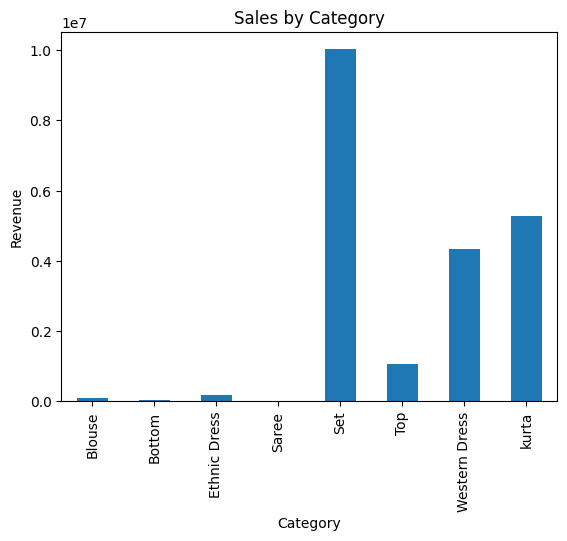

In [25]:
#Exploratory Data Analysis
#sales by category
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Amount'].sum()

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

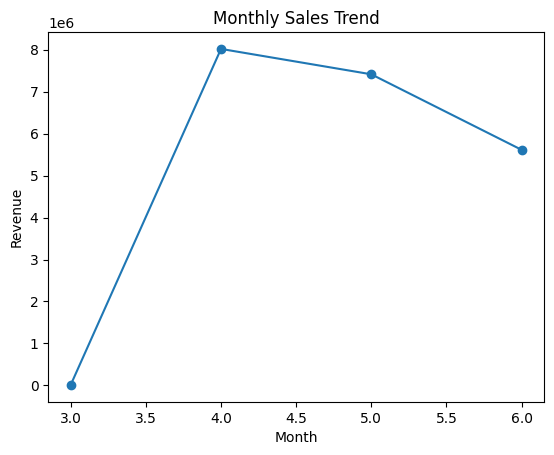

In [27]:
#Monthly sales
df['Month']= df['Date'].dt.month
monthly_sales = df.groupby('Month')['Amount'].sum()

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

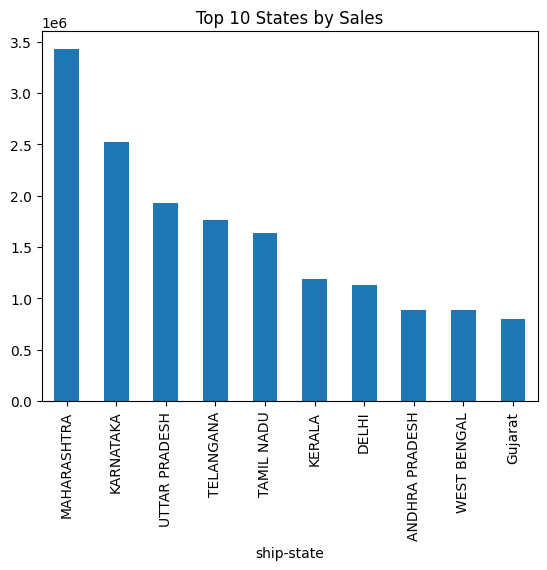

In [28]:
#Top 10 statesales
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')

plt.title('Top 10 States by Sales')
plt.show()

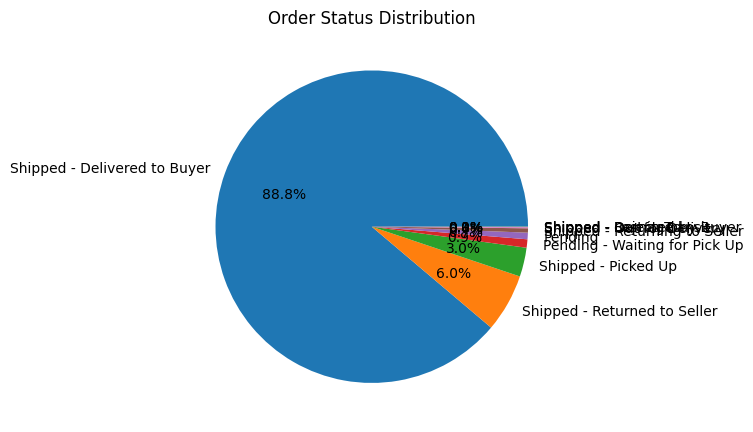

In [37]:
#Order Status
status_counts = df['Status'].value_counts()
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Order Status Distribution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2411/4252817565.py:5: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


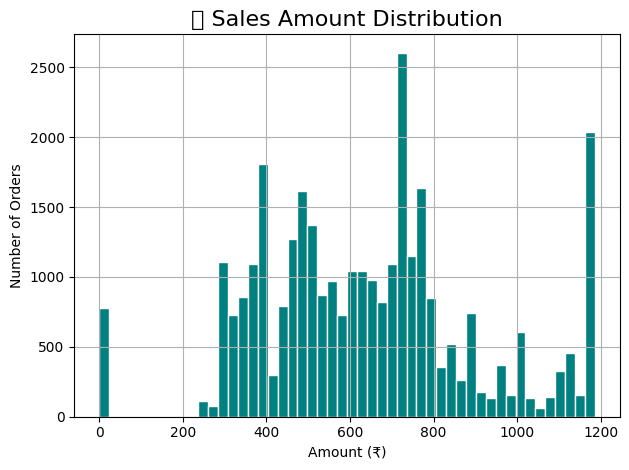

In [41]:
#No of order by sales
df['Amount'].clip(upper=df['Amount'].quantile(0.95)).hist(bins=50, color='teal', edgecolor='white')
plt.title('Sales Amount Distribution', fontsize=16)
plt.xlabel('Amount (₹)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2411/2612840563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=b2b_sales.index, y=b2b_sales.values, palette='coolwarm')


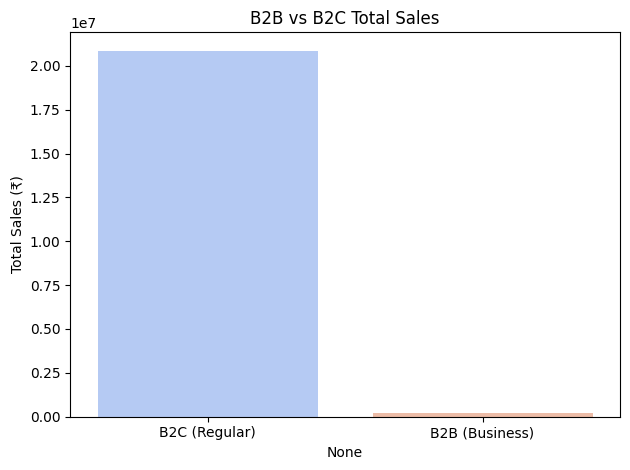

In [42]:
#B2B VS B2C Sales
b2b_sales = df.groupby('B2B')['Amount'].sum()
b2b_sales.index = ['B2C (Regular)', 'B2B (Business)']
sns.barplot(x=b2b_sales.index, y=b2b_sales.values, palette='coolwarm')
plt.title('B2B vs B2C Total Sales')
plt.ylabel('Total Sales (₹)')
plt.tight_layout()
plt.show()

Prediction analysis using machine learning

In [43]:
df = pd.get_dummies(df, drop_first=True)

In [44]:
print(df.shape)

(32338, 79)


In [45]:
df = df.drop('Date', axis=1, errors='ignore')

In [46]:
#defining x and y variables
X = df.drop('Amount', axis=1)

y = df['Amount']

In [47]:
#train-test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
# training model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
#making prediction

predictions = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 161.33301421693926
R2 Score: 0.3376458602798085


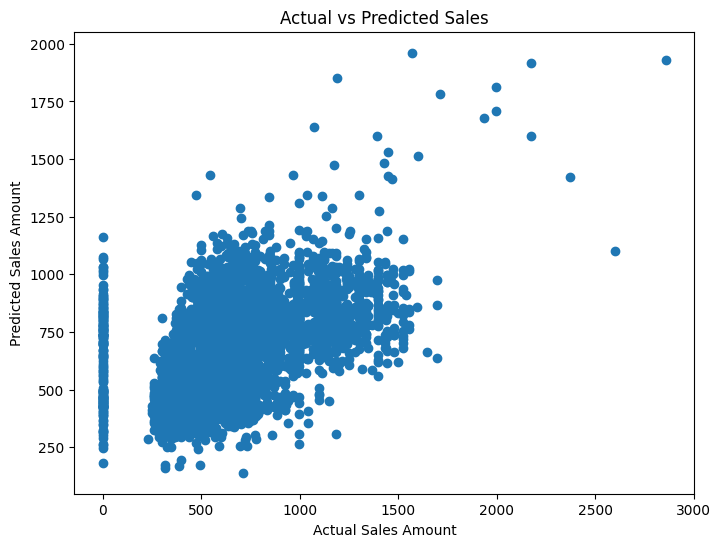

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.title("Actual vs Predicted Sales")

plt.show()

In [54]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(10))

Category_kurta                         0.415673
Day                                    0.109942
Category_Top                           0.101770
WeekDay                                0.064271
Qty                                    0.050746
Category_Set                           0.026162
Month                                  0.019527
Category_Bottom                        0.013173
Status_Shipped - Delivered to Buyer    0.011850
Status_Shipped - Returned to Seller    0.011222
dtype: float64


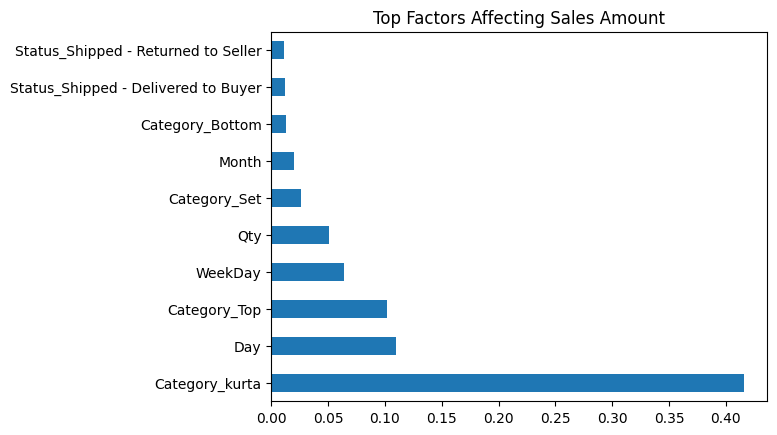

In [55]:
importance.head(10).plot(kind='barh')

plt.title(
    "Top Factors Affecting Sales Amount"
)

plt.show()

In [56]:
importance.head(10)

,0
Category_kurta,0.415673
Day,0.109942
Category_Top,0.101770
WeekDay,0.064271
Qty,0.050746
Category_Set,0.026162
Month,0.019527
Category_Bottom,0.013173
Status_Shipped - Delivered to Buyer,0.011850
Status_Shipped - Returned to Seller,0.011222
